In [1]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction, user_similarities

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import functional as F
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error
import random
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors, NeighborhoodComponentsAnalysis
from sklearn.metrics import pairwise_distances
import pickle
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML
from lib.matrix_dataset import MatrixDataset
from recommenders.vae import MultiVAE

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    device = mps_device
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print ("MPS device not found.")

if device == torch.device("cuda"):
    dtype = torch.float32
    print("Using CUDA.")
elif device == torch.device("cpu"):
    dtype = torch.float64
    print("Using CPU.")
elif device == torch.device("mps"):
    dtype = torch.float32
    print("Using MPS.")

# device = "cpu"
# dtype = torch.float32

tensor([1.], device='mps:0')
Using MPS.


# Import data

In [3]:
df = spoti.load_all_tracks(
    base_path=data_path.DATA_PATH,
    users=users_list.USERS,
    load_spotify_tracks=False,
    penality_factors={"short_term": 1, "medium_term": 1, "long_term": 1},
)
df

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,1.00,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.98,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.96,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.94,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.92,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12424,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,NaN,dany,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12425,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,193853,False,{'isrc': 'GBLTP1700005'},{'spotify': 'https://open.spotify.com/track/1V...,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,1VofMhhL98pewltVGBSmCW,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:07+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12426,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY...,0KE7apgczHNYiXIvMUY0Fc,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:13+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12427,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,467306,False,{'isrc': 'GBLTP1700014'},{'spotify': 'https://open.spotify.com/track/6v...,https://api.spotify.com/v1/tracks/6vbRA9yAAgIX...,6vbRA9yAAgIXtDlmhyNqPq,...,NaN,N

# Logistic Matrix Factorization for Implicit Feedback Data (Logistic MF)
From [Christopher C. Johnson - Logistic Matrix Factorization for Implicit Feedback Data](https://web.stanford.edu/~rezab/nips2014workshop/submits/logmat.pdf)

## Setup the dataset

In [4]:
df_matrix_mf = df.copy()
df_matrix_mf.loc[df_matrix_mf["type"] == "liked_track", "affinity"] = 0.5
df_matrix_mf.loc[df_matrix_mf["type"] == "playlist", "affinity"] = 0.3

used_types = ["top_track", "liked_track", "playlist"]
# used_types = ["top_track"]
df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]
df_matrix_mf[["username", "id", "affinity"] + spoti.NUMERICAL_FEATURES]
df_matrix_mf["affinity"] *= 100

In [5]:
df_matrix_mf = pd.read_csv(os.path.join(data_path.DATA_PATH, "artificial_data.csv"), index_col=0)

In [6]:
matrix_mf = MatrixDataset(df_matrix_mf, "username", "id", "affinity", device=device, dtype=dtype)
user_interacted_with = matrix_mf.R
user_interacted_with

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 1.0496,  ..., 0.0000, 0.0000, 0.0000]],
       device='mps:0')

In [7]:
user_interacted_with.shape

torch.Size([497, 53477])

In [8]:
alpha = matrix_mf.compute_alpha().item()
user_interacted_with *= alpha
alpha

353.5196533203125

In [9]:
users, items = user_interacted_with.shape

# Define and train the MultiVAE model

In [10]:
batch_size = 32

train_set = user_interacted_with
train_dataset = TensorDataset(train_set)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [11]:
# Define dimensions for the encoder and decoder
encoder_dims = [user_interacted_with.shape[1], 800, 500, 2]
decoder_dims = encoder_dims[::-1]  # Symmetric decoder
model = MultiVAE(encoder_dims, decoder_dims, dropout_rate=0.5, device=device, dtype=dtype)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0)

model.train_model(
    train_loader,
    optimizer=optimizer,
    num_epochs=1000,
    max_anneal=1.0,
    anneal_steps=2000,
    log_interval=10
)

Epoch: 0, Step: 10, Loss: 614628.5, Anneal: 0.004999999888241291
Epoch: 1, Step: 20, Loss: 575620.75, Anneal: 0.009999999776482582
Epoch: 1, Step: 30, Loss: 594869.3125, Anneal: 0.014999999664723873
Epoch: 2, Step: 40, Loss: 577243.125, Anneal: 0.019999999552965164
Epoch: 3, Step: 50, Loss: 538057.9375, Anneal: 0.02500000037252903
Epoch: 3, Step: 60, Loss: 558254.375, Anneal: 0.029999999329447746
Epoch: 4, Step: 70, Loss: 545746.125, Anneal: 0.03500000014901161
Epoch: 4, Step: 80, Loss: 559191.125, Anneal: 0.03999999910593033
Epoch: 5, Step: 90, Loss: 546067.8125, Anneal: 0.04500000178813934
Epoch: 6, Step: 100, Loss: 540405.875, Anneal: 0.05000000074505806
Epoch: 6, Step: 110, Loss: 541983.4375, Anneal: 0.054999999701976776
Epoch: 7, Step: 120, Loss: 535024.0, Anneal: 0.05999999865889549
Epoch: 8, Step: 130, Loss: 509865.0, Anneal: 0.06499999761581421
Epoch: 8, Step: 140, Loss: 531612.0, Anneal: 0.07000000029802322
Epoch: 9, Step: 150, Loss: 529166.125, Anneal: 0.07500000298023224
Epo

KeyboardInterrupt: 

In [12]:
losses = model.losses.cpu().detach().numpy()
go.Figure(
    data=[
        go.Scatter(
            x=list(range(len(losses))),
            y=losses,
            name="Train Loss",
            mode="lines",
        ),
    ],
    layout=go.Layout(
        title="Training and Validation Loss",
        xaxis=dict(title="Epoch"),
        yaxis=dict(title="Loss"),
    ),
)

In [15]:
# retrieve users latent representations (mean and variance)
usersnames = matrix_mf.get_usernames()

model.eval()
with torch.no_grad():
    mu, logvar = model.encode(user_interacted_with)
    z = model.reparameterize(mu, logvar)
    z = z.cpu().numpy()
    mu = mu.cpu().numpy()
    std = np.exp(0.5 * logvar.cpu().numpy())
    logvar = logvar.cpu().numpy()

print(z)
print(mu)
print(logvar)

[[  3.392078    -4.128499  ]
 [ -3.1752653    0.4421927 ]
 [  2.9817748   -5.8363028 ]
 [  5.163538     1.8920287 ]
 [  2.407845    -0.8980461 ]
 [ -1.5296389    5.9488583 ]
 [ -5.828653    -9.655189  ]
 [  5.2752347   -0.31467208]
 [ -7.093719     0.71703035]
 [ -3.5604467   -6.785781  ]
 [ -3.4659781    5.827536  ]
 [  9.865645     3.5728474 ]
 [ -3.643322     5.877103  ]
 [  0.1975485    1.545134  ]
 [ -3.0775292   -5.8486137 ]
 [ -4.043646    -6.9163637 ]
 [ -4.67448      8.105981  ]
 [  1.7435757    9.72061   ]
 [  1.988583    -2.9185061 ]
 [  5.796738    -0.02307121]
 [ -3.916229    -7.2123055 ]
 [ -4.1924157   -5.8641596 ]
 [  2.6700625    0.16520427]
 [  1.5283287   -6.5026093 ]
 [  0.8397729   -4.758701  ]
 [  5.615867     5.2369375 ]
 [  3.5399768    7.1004558 ]
 [  1.9487742    1.2796963 ]
 [  3.374672    -1.4626038 ]
 [  2.9470754   -1.8572487 ]
 [  1.1581773    5.3221426 ]
 [  2.5662441   -8.018186  ]
 [  8.753531     2.965706  ]
 [  5.2019434    0.4609917 ]
 [ -9.517888  

In [14]:
# Define the number of points for grid, the width of the gaussian curves and color map
if encoder_dims[-1] == 2:
    # Plot 2D latent space using and add annotations with usernames
    fig = px.scatter(x=z[:, 0], y=z[:, 1], hover_name=usersnames, color=usersnames)
    fig.update_traces(marker=dict(size=10))
    fig.update_layout(title="2D Latent Space")
    # Show the usernames next to the points
    for i, username in enumerate(usersnames):
        fig.add_annotation(
            x=z[i, 0], y=z[i, 1], text=username, showarrow=False, xshift=-20, yshift=15
        )
    fig.show()
    
    plotting.plot_multivariate_gaussian_image_with_labels(mu, std, usersnames)

KeyboardInterrupt: 

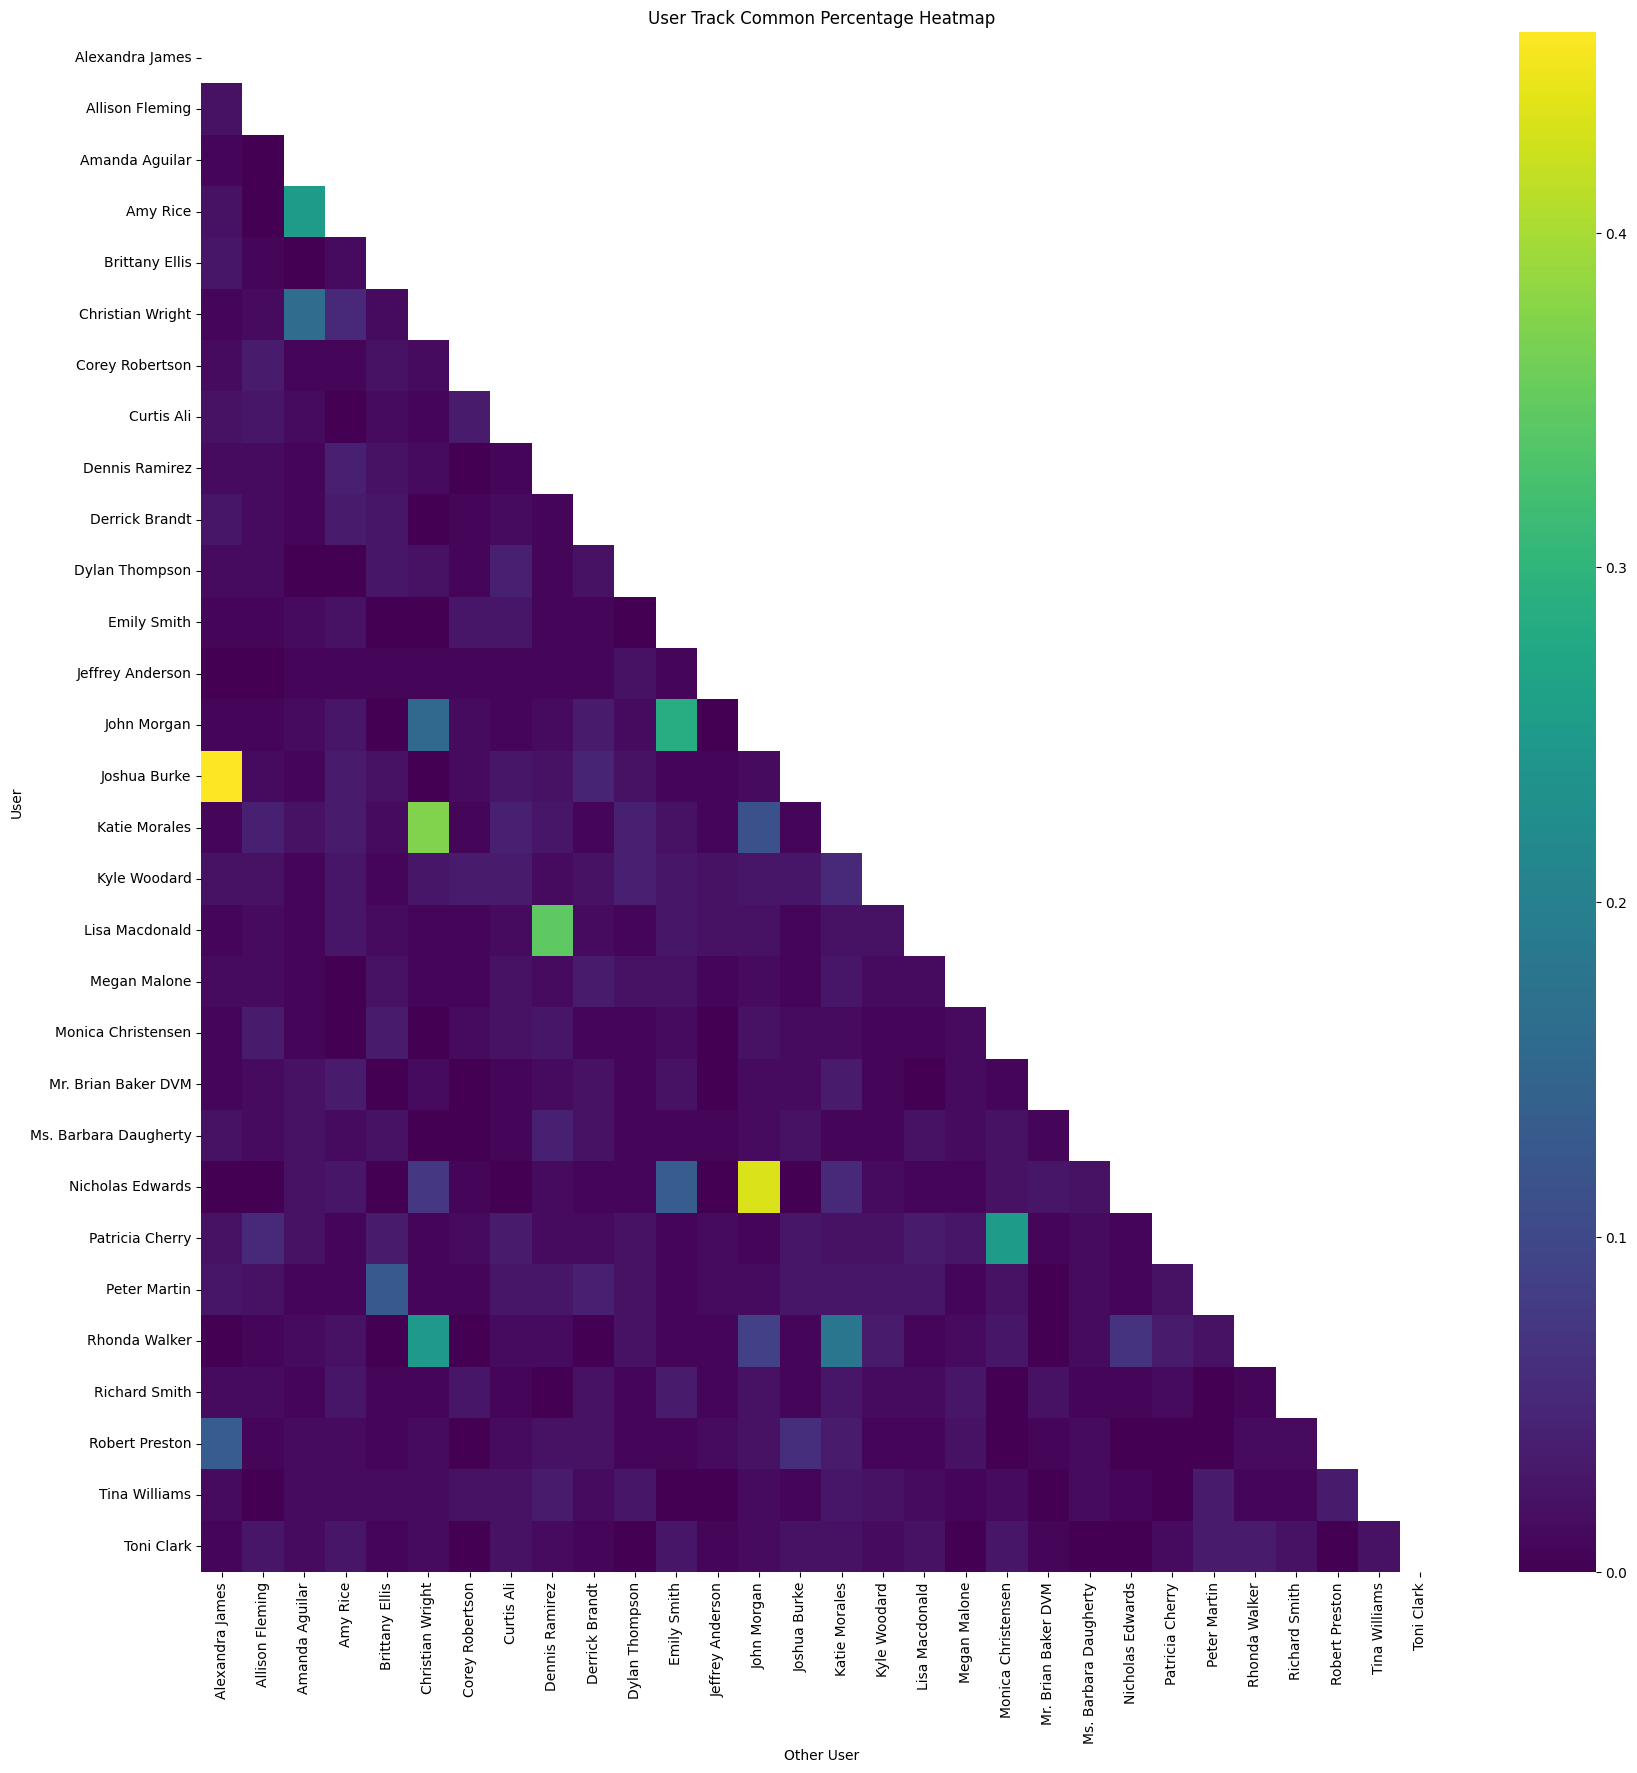

In [ ]:
df_user_similarities = user_similarities.calculate_users_track_common_percentage(df_matrix_mf, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20))

In [ ]:
user = "Joshua Burke"
user_idx = matrix_mf.usernames_to_ids([user])[0]
user_data = matrix_mf.get_user(user_idx).to(device).unsqueeze(0)
user_interacted_with = matrix_mf.user_interacted_with(user_idx)

recommended_items_ids = model.recommend_items(user_data, user_interacted_with, top_k=10)
recommended_items_ids

recommended_items = matrix_mf.ids_to_itemnames(recommended_items_ids)
df_recommended_items = df_matrix_mf[df_matrix_mf["id"].isin(recommended_items)]
df_recommended_items

,id,username,danceability,duration_ms,instrumentalness,affinity
179,Traditional,Richard Smith,1.051902,1.120439,1.015211,0.905702
338,Participant,Dennis Ramirez,1.114397,1.174603,1.208407,0.920961
396,Scientist,Dennis Ramirez,1.042309,1.001556,0.990883,0.781570
478,Participant,Allison Fleming,1.091659,0.910022,0.992128,0.970520
517,Participant,Allison Fleming,0.884679,0.821961,1.222572,1.034711
552,Traditional,Allison Fleming,0.993766,1.119801,0.936801,0.869920
567,Positive,Allison Fleming,1.034210,0.996512,0.932288,1.028067
901,Participant,Monica Christensen,0.864479,0.890687,1.107853,0.997599
1142,Scientist,Megan Malone,1.066195,1.018074,0.970018,0.731167
1162,Because,Megan Malone,0.979024,1.015850,1.192272,0.969212
